#  **LABORATORIO 9**

## Luciana Carabaguiaz, Diego Diaz, Julián Maroto, Santiago Volio

# RETO 1


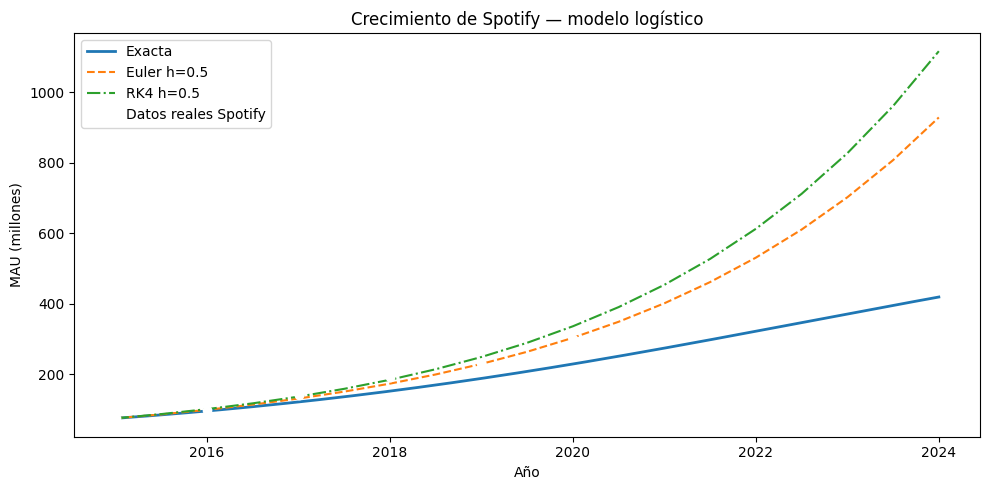

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Parámetros del modelo logístico ────────────
r  = 0.28   # tasa de crecimiento anual de Spotify
K  = 700    # mercado alcanzable estimado (millones)
U0 = 75     # usuarios en 2015 (millones)
t0, tf = 0, 9   # 2015 → 2024
h  = 0.5    # ← cambia esto y observa el error

# ─── ODE logística ──────────────────────────────
f = lambda t, U: r * U * (1 - U / K)

# ─── Solución exacta ────────────────────────────
t_ex = np.linspace(t0, tf, 300)
U_ex = (K * U0 * np.exp(r * t_ex)) / (K - U0 + U0 * np.exp(r * t_ex))

# ─── Datos reales de referencia (MAU millones) ──
años_reales  = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
mau_reales   = [75, 100, 140, 191, 232, 299, 365, 422, 515, 602]

# ─── TODO: implementa Euler ─────────────────────
def euler(f, y0, t0, tf, h):
    t, y = [t0], [y0]
    while t[-1] < tf:
        tn = t[-1]
        yn = y[-1]
        t.append(tn + h)
        y.append(yn + h * f(tn, yn))
    return t, y

# Ejemplo: dy/dt = 0.3y, y(0) = 50
f = lambda t, y: 0.3 * y
t, y = euler(f, 50, 0, 10, h=0.5)

# ─── TODO: implementa RK4 ───────────────────────
def runge_kutta4(f, y0, t0, tf, h):
    t, y = [t0], [y0]
    while t[-1] < tf:
        tn, yn = t[-1], y[-1]
        k1 = f(tn,        yn)
        k2 = f(tn + h/2, yn + h*k1/2)
        k3 = f(tn + h/2, yn + h*k2/2)
        k4 = f(tn + h,   yn + h*k3)
        t.append(tn + h)
        y.append(yn + (h/6) * (k1 + 2*k2 + 2*k3 + k4))
    return t, y

# ─── Grafica ────────────────────────────────────
t_e, U_e = euler(f, U0, t0, tf, h)
t_r, U_r = runge_kutta4(f, U0, t0, tf, h)
años = [2015+i for i in años_reales]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([2015+t for t in t_ex], U_ex, label='Exacta', lw=2)
ax.plot([2015+t for t in t_e],  U_e,  label=f'Euler h={h}', ls='--')
ax.plot([2015+t for t in t_r],  U_r,  label=f'RK4 h={h}', ls='-.')
ax.scatter(años, mau_reales, color='white', zorder=5, label='Datos reales Spotify')
ax.set(xlabel='Año', ylabel='MAU (millones)', title='Crecimiento de Spotify — modelo logístico')
ax.legend(); plt.tight_layout(); plt.show()

## Objetivo
Modelar el crecimiento de usuarios de Spotify usando una ecuación diferencial y comparar:

- Solución exacta
- Método de Euler
- Método RK4
- Datos reales

Además, analizar cómo el tamaño de paso \(h\) afecta la precisión.

---

## Modelo matemático

Se utiliza el **modelo logístico**:

\[
\frac{dU}{dt} = rU\left(1 - \frac{U}{K}\right)
\]

### Interpretación:
- \(U(t)\): usuarios activos (millones)
- \(r\): tasa de crecimiento
- \(K\): límite máximo del mercado (capacidad)
- \(U_0\): valor inicial

Este modelo describe crecimiento que:
- al inicio es exponencial  
- luego se desacelera  
- finalmente se estabiliza en \(K\)

---

## Parámetros del modelo

```python
r  = 0.28
K  = 700
U0 = 75
t0, tf = 0, 9
h  = 0.5

# RETO 2

Valor exacto en 2024: 419.0370 millones


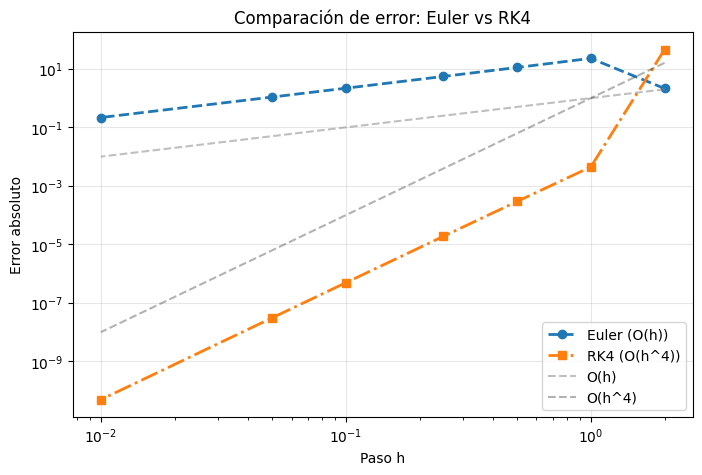


Error con h=1:
Euler: 22.84 millones
RK4:   0.0044 millones


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Parámetros ────────────────────────────────
r, K, U0 = 0.28, 700, 75
t_final  = 9
f = lambda t, U: r * U * (1 - U / K)

# ─── Solución exacta ──────────────────────────
U_exacta = (K * U0 * np.exp(r * t_final)) / \
           (K - U0 + U0 * np.exp(r * t_final))

print(f"Valor exacto en 2024: {U_exacta:.4f} millones")

# ─── Método de Euler ──────────────────────────
def euler(f, y0, t0, tf, h):
    t_vals = np.arange(t0, tf + h, h)
    y_vals = np.zeros(len(t_vals))
    y_vals[0] = y0

    for i in range(len(t_vals) - 1):
        y_vals[i+1] = y_vals[i] + h * f(t_vals[i], y_vals[i])

    return t_vals, y_vals

# ─── Método RK4 ───────────────────────────────
def runge_kutta4(f, y0, t0, tf, h):
    t_vals = np.arange(t0, tf + h, h)
    y_vals = np.zeros(len(t_vals))
    y_vals[0] = y0

    for i in range(len(t_vals) - 1):
        t, y = t_vals[i], y_vals[i]

        k1 = f(t, y)
        k2 = f(t + h/2, y + h*k1/2)
        k3 = f(t + h/2, y + h*k2/2)
        k4 = f(t + h, y + h*k3)

        y_vals[i+1] = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

    return t_vals, y_vals

# ─── Pasos ────────────────────────────────────
h_vals = [2.0, 1.0, 0.5, 0.25, 0.1, 0.05, 0.01]

errores_euler = []
errores_rk4   = []

for h in h_vals:
    _, U_e = euler(f, U0, 0, t_final, h)
    errores_euler.append(abs(U_e[-1] - U_exacta))

    _, U_r = runge_kutta4(f, U0, 0, t_final, h)
    errores_rk4.append(abs(U_r[-1] - U_exacta))

# ─── Gráfica log-log ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(h_vals, errores_euler, 'o--', label='Euler (O(h))', lw=2)
ax.loglog(h_vals, errores_rk4,   's-.', label='RK4 (O(h^4))', lw=2)

# Referencias teóricas
h_ref = np.array(h_vals)
ax.loglog(h_ref, h_ref, '--', color='gray', alpha=.5, label='O(h)')
ax.loglog(h_ref, h_ref**4, '--', color='black', alpha=.3, label='O(h^4)')

ax.set(xlabel='Paso h',
       ylabel='Error absoluto',
       title='Comparación de error: Euler vs RK4')

ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# ─── Errores específicos en h=1 ───────────────
h_test = 1.0

_, U_e = euler(f, U0, 0, t_final, h_test)
_, U_r = runge_kutta4(f, U0, 0, t_final, h_test)

error_euler = abs(U_e[-1] - U_exacta)
error_rk4   = abs(U_r[-1] - U_exacta)

print(f"\nError con h=1:")
print(f"Euler: {error_euler:.2f} millones")
print(f"RK4:   {error_rk4:.4f} millones")

## Objetivo
Analizar cómo cambia el error numérico al variar el tamaño del paso \(h\) en dos métodos:

- Método de Euler (orden 1)
- Método Runge-Kutta de orden 4 (RK4)

Se busca verificar experimentalmente su orden de convergencia.

---

## Modelo utilizado

Se trabaja con el modelo logístico:

\[
\frac{dU}{dt} = rU\left(1 - \frac{U}{K}\right)
\]

Donde:
- \(U(t)\): número de usuarios
- \(r\): tasa de crecimiento
- \(K\): capacidad máxima (mercado)
- \(U_0\): valor inicial

---

## Solución exacta

Se calcula la solución analítica en \(t = 9\):

\[
U(t) = \frac{K U_0 e^{rt}}{K - U_0 + U_0 e^{rt}}
\]

Esta solución sirve como referencia para medir el error de los métodos numéricos.

---

## Métodos numéricos

### Método de Euler

\[
U_{n+1} = U_n + h f(t_n, U_n)
\]

- Método simple
- Orden de error global: \(O(h)\)

---

### Método RK4

\[
U_{n+1} = U_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\]

Donde:
- \(k_1 = f(t, U)\)
- \(k_2 = f(t + h/2, U + hk_1/2)\)
- \(k_3 = f(t + h/2, U + hk_2/2)\)
- \(k_4 = f(t + h, U + hk_3)\)

- Mucho más preciso
- Orden de error global: \(O(h^4)\)

---

## Análisis de error

Para distintos valores de \(h\):

```python
h_vals = [2.0, 1.0, 0.5, 0.25, 0.1, 0.05, 0.01]

# **RETO 3**



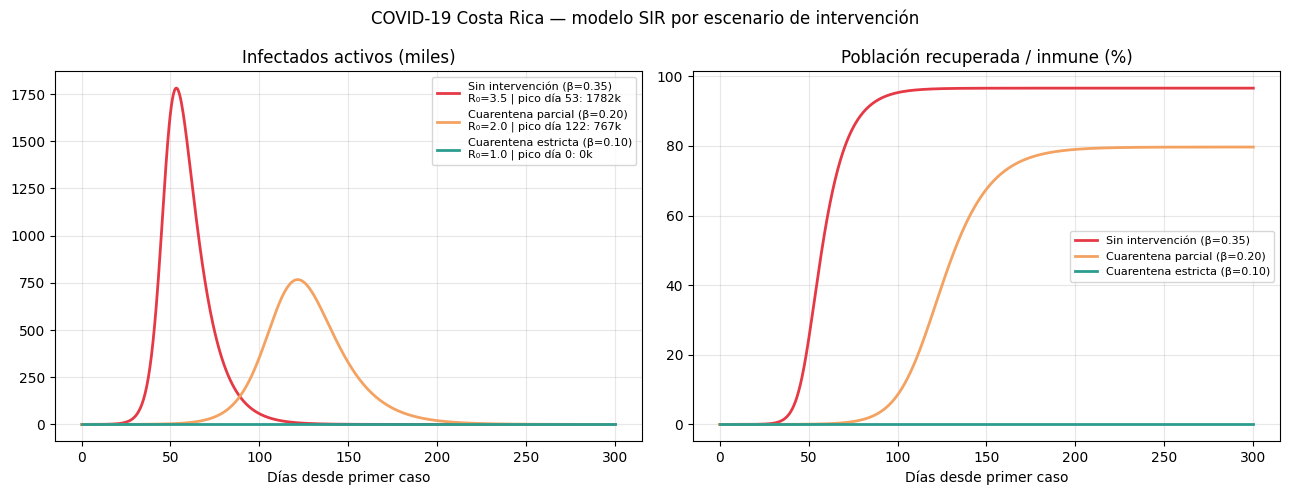

Maximum beta value that keeps peak infections within ICU capacity: 0.117
Corresponding peak number of infected individuals: 3646
ICU beds required at this peak: 182


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ─── Costa Rica, marzo 2020 ─────────────────────
N   = 5_000_000
I0  = 23         # casos confirmados al inicio
S0  = N - I0
R0i = 0
y0  = [S0, I0, R0i]

# ─── Escenarios ─────────────────────────────────
escenarios = {
    'Sin intervención (β=0.35)': (0.35, '#e63946'),
    'Cuarentena parcial (β=0.20)': (0.20, '#f4a261'),
    'Cuarentena estricta (β=0.10)': (0.10, '#2a9d8f'),
}
gam = 0.10   # γ = 1/10 días → recuperación en ~10 días

# ─── Sistema de ODEs SIR ────────────────────────
def sir(t, y, beta):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt =  beta * S * I / N - gam * I
    dRdt =  gam * I
    return [dSdt, dIdt, dRdt]

# ─── Simulación y visualización ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
t_span = (0, 300)
t_eval = np.linspace(0, 300, 1000)

for nombre, (beta, color) in escenarios.items():
    sol = solve_ivp(sir, t_span, y0,
                   args=(beta,), method='RK45',
                   t_eval=t_eval, max_step=0.5)
    S, I, R = sol.y
    R0_num = beta / gam

    pico_d = t_eval[np.argmax(I)]
    pico_v = np.max(I)

    axes[0].plot(t_eval, I/1000, color=color, lw=2,
                label=f'{nombre}\nR₀={R0_num:.1f} | pico día {pico_d:.0f}: {pico_v/1000:.0f}k')
    axes[1].plot(t_eval, R/N*100, color=color, lw=2, label=nombre)

axes[0].set(title='Infectados activos (miles)',
           xlabel='Días desde primer caso')
axes[1].set(title='Población recuperada / inmune (%)',
           xlabel='Días desde primer caso')
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.suptitle('COVID-19 Costa Rica — modelo SIR por escenario de intervención')
plt.tight_layout(); plt.show()

# ─── TODO: ¿Cuántas camas UCI se necesitarían? ──
icu_beds_capacity = 240
icu_percentage = 0.05
max_allowed_infections = icu_beds_capacity / icu_percentage

t_span = (0, 300)
t_eval = np.linspace(0, 300, 1000)

peak_infections = []
valid_betas = []

beta_vals = np.arange(0.05, 0.40, 0.001)
for beta in beta_vals:
    sol = solve_ivp(sir, t_span, y0,
                   args=(beta,), method='RK45',
                   t_eval=t_eval, max_step=0.5)
    I = sol.y[1] # Infected individuals are the second component
    peak_I = np.max(I)
    peak_infections.append(peak_I)

    if peak_I <= max_allowed_infections:
        valid_betas.append(beta)
max_beta = np.max(valid_betas)
peak_I_max_beta = np.max(peak_infections)
icu_beds_required = peak_I_max_beta * icu_percentage

max_beta = np.max(valid_betas)

# Rerun simulation for the max_beta to get exact peak_I
sol_max_beta = solve_ivp(sir, t_span, y0,
                       args=(max_beta,), method='RK45',
                       t_eval=t_eval, max_step=0.5)

I_max_beta = sol_max_beta.y[1]
peak_I_max_beta = np.max(I_max_beta)
icu_beds_required = peak_I_max_beta * icu_percentage

print(f"Maximum beta value that keeps peak infections within ICU capacity: {max_beta:.3f}")
print(f"Corresponding peak number of infected individuals: {peak_I_max_beta:.0f}")
print(f"ICU beds required at this peak: {icu_beds_required:.0f}")

## Objetivo
Simular la propagación del COVID-19 en Costa Rica usando el modelo SIR y analizar:

- Diferentes escenarios de intervención
- Evolución de infectados y recuperados
- Capacidad del sistema de salud (UCI)

---

## Modelo matemático (SIR)

El modelo SIR divide la población en tres grupos:

- \(S(t)\): susceptibles  
- \(I(t)\): infectados  
- \(R(t)\): recuperados  

Sistema de ecuaciones:

\[
\frac{dS}{dt} = -\beta \frac{SI}{N}
\]
\[
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
\]
\[
\frac{dR}{dt} = \gamma I
\]

---

## Interpretación de parámetros

- \(N\): población total (5,000,000)
- \(\beta\): tasa de contagio
- \(\gamma\): tasa de recuperación
- \(R_0 = \frac{\beta}{\gamma}\): número reproductivo básico

Si:
- \(R_0 > 1\): la epidemia crece  
- \(R_0 < 1\): la epidemia se controla  

---

## Condiciones iniciales

```python
N = 5_000_000
I0 = 23
S0 = N - I0
R0i = 0